# State-wise Agricultural Production Analysis (India)
---
## Objective
This project analyzes agricultural production patterns across Indian states using three key metrics:

- Production (MT)
- Cultivated Area (MHA)
- Yield (Kg per Hectare)

*Note:* `MT- Million Tonnes`, `MHA - Million Hectares`

---
The analysis aims to answer:
1. Which states dominate agricultural production?
2. Is production concentrated in a few states?
3. Are high-production states also the most efficient?
4. How does cultivated area influence production?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## *1. Data Overview & Cleaning*
---
This section examines the structure of the dataset, including column types,
missing values, and basic statistics. Understanding the dataset helps identify
data quality issues before performing analysis.

In [2]:
# load the data
df = pd.read_csv("../data/clean/agristats_clean.csv")
df.head()

,crop,state,season,year,area,production,yield,area_mha,production_mt,data_quality_flag,crop_category
0,Rice,Andaman And Nicobar Islands,Kharif,2020-21,6256.0,13344.05,2133.0,0.006256,0.013344,GOOD,food_grains
1,Rice,Andhra Pradesh,Kharif,2020-21,1496000.0,4211240.00,2815.0,1.496000,4.211240,GOOD,food_grains
2,Rice,Andhra Pradesh,Rabi,2020-21,827500.0,3671617.50,4437.0,0.827500,3.671617,GOOD,food_grains
3,Rice,Arunachal Pradesh,Kharif,2020-21,133270.0,246416.23,1849.0,0.133270,0.246416,GOOD,food_grains
4,Rice,Arunachal Pradesh,Rabi,2020-21,495.0,663.30,1340.0,0.000495,0.000663,GOOD,food_grains


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5459 entries, 0 to 5458
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop               5459 non-null   object 
 1   state              5459 non-null   object 
 2   season             5459 non-null   object 
 3   year               5459 non-null   object 
 4   area               5205 non-null   float64
 5   production         5455 non-null   float64
 6   yield              5205 non-null   float64
 7   area_mha           5205 non-null   float64
 8   production_mt      5455 non-null   float64
 9   data_quality_flag  5459 non-null   object 
 10  crop_category      5459 non-null   object 
dtypes: float64(5), object(6)
memory usage: 469.3+ KB


In [4]:
df.isnull().sum()

crop                   0
state                  0
season                 0
year                   0
area                 254
production             4
yield                254
area_mha             254
production_mt          4
data_quality_flag      0
crop_category          0
dtype: int64

In [5]:
df.data_quality_flag.value_counts()

data_quality_flag
GOOD               4734
ZERO_PRODUCTION     467
INSUFFICIENT        258
Name: count, dtype: int64

Rows labeled as "INSUFFICIENT" indicate unreliable or incomplete data.<br>
These records are removed to ensure analytical accuracy.

In [6]:
# df = df[df["data_quality_flag"] != "INSUFFICIENT"].drop(columns=['area', 'production', 'data_quality_flag'])
df = (
    df[df["data_quality_flag"] != "INSUFFICIENT"]
    .drop(columns=['area', 'production', 'data_quality_flag'])
    .reset_index(drop=True)
)

In [7]:
df.describe()

,yield,area_mha,production_mt
count,5201.000000,5201.000000,5201.000000
mean,3150.967699,0.311857,1.190678
std,11296.157164,0.953312,7.915604
min,0.000000,0.000000,0.000000
25%,635.000000,0.000688,0.000728
50%,1105.000000,0.010620,0.015621
75%,2182.000000,0.136000,0.236037
max,140000.000000,10.099000,224.245870


***Insights***:
- Dataset contains 5201 records for all variables (no missing values).
- All features (yield, area_mha, production_mt) are highly right-skewed (mean >> median).
- Presence of extreme outliers, especially in yield and production_mt.
- High variability indicated by large standard deviations.
- Majority of values are clustered at lower ranges, with few very large observations.

## *2. Distribution Analysis*
---
This section analyzes the distribution of production, area, and yield.
Understanding the distribution helps identify skewness, outliers, and
structural concentration in agricultural production.

In [8]:
numeric_features = df.select_dtypes(exclude = object).columns
categorical_features = df[['crop', 'state', 'season', 'crop_category']].columns
year = df[["year"]].columns

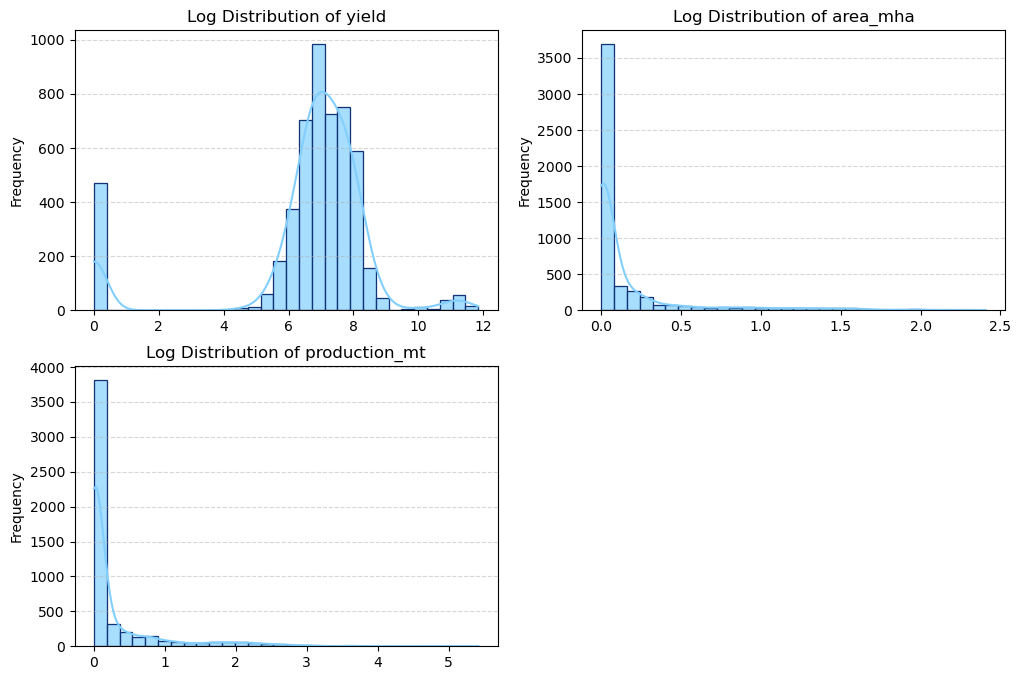

In [9]:
import math

# Columns to plot
cols = len(numeric_features)

# Automatic grid layout
cols_per_row = 2  # Adjust as needed
rows = math.ceil(cols / cols_per_row)

plt.figure(figsize=(cols_per_row * 6, rows * 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols_per_row, i)
    
    # Log transform (safe for zeros)
    transformed = np.log1p(df[col])
    
    sns.histplot(
        x=transformed,
        kde=True,
        bins=30,
        color="#82CFFD",
        edgecolor="#137",
        alpha=0.7
    )
    
    plt.title(f'Log Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

***Distribution Characteristics*** <br>
Production and area exhibit strong positive skewness, indicating structural concentration in a limited number of states whereas Yield distribution shows less extreme dispersion, suggesting moderate variability in efficiency.

In [10]:
print("Yield:", np.log1p(df['yield']).skew())
print("Area:", np.log1p(df['area_mha']).skew())
print("Production:", np.log1p(df['production_mt']).skew())

Yield: -1.9196912654960365
Area: 3.104847026056557
Production: 3.084589593463793


***Distribution of Key Variables*** <br>
Production and cultivated area exhibit strong positive skewness even after log transformation, indicating that a small number of states operate at significantly larger scale than the majority. <br>
Yield shows moderate negative skewness, suggesting that while extremely high-yield states exist, most states cluster around mid-level productivity.<br>
This confirms early evidence of structural imbalance in scale distribution across states.

## *3. Production Concentration Analysis*
---
To understand how agricultural production is distributed across India, we analyze the share of total production contributed by each state.This analysis helps determine whether production is evenly distributed across states or concentrated in a few dominant regions.


In [11]:
state_prod = (
    df.groupby("state")["production_mt"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

In [12]:
total_production = state_prod["production_mt"].sum()
total_production

np.float64(6192.71589981)

In [13]:
state_prod["share_%"] = (
    state_prod["production_mt"] / total_production
) * 100

state_prod["cumulative_share_%"] = state_prod["share_%"].cumsum()


In [14]:
state_prod

,state,production_mt,share_%,cumulative_share_%
0,Uttar Pradesh,1643.292644,26.535896,26.535896
1,Maharashtra,824.655368,13.316538,39.852434
2,Madhya Pradesh,489.750541,7.908494,47.760928
3,Karnataka,451.082840,7.284087,55.045015
4,Punjab,350.748392,5.663886,60.708901
5,Rajasthan,348.115562,5.621371,66.330273
6,Bihar,271.214018,4.379565,70.709838
7,Gujarat,259.124141,4.184338,74.894175
8,West Bengal,258.493344,4.174152,79.068327
9,Haryana,244.632645,3.950329,83.018656


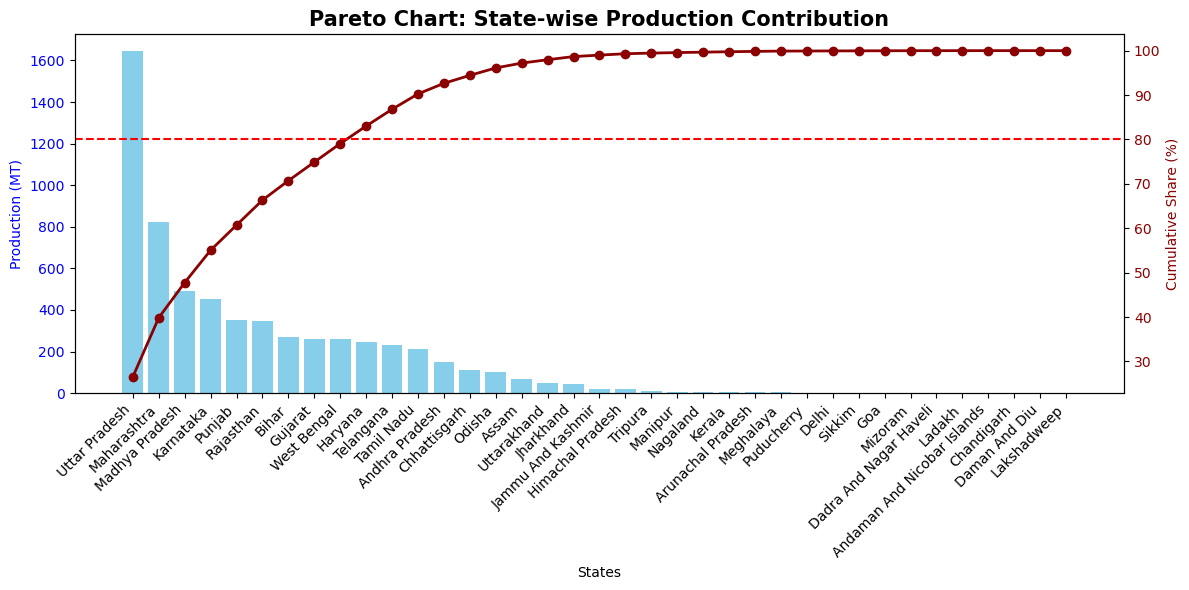

In [15]:
# Create rank
state_prod["rank"] = range(1, len(state_prod) + 1)

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot for production
ax1.bar(
    state_prod["state"],
    state_prod["production_mt"],
    color="skyblue"
)

ax1.set_xlabel("States")
ax1.set_ylabel("Production (MT)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Rotate state names
plt.xticks(rotation=45, ha="right")

# Second axis for cumulative %
ax2 = ax1.twinx()

ax2.plot(
    state_prod["state"],
    state_prod["cumulative_share_%"],
    color="darkred",
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Cumulative Share (%)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

# 80% reference line
ax2.axhline(80, color="red", linestyle="--", label="80% Threshold")

plt.title("Pareto Chart: State-wise Production Contribution", fontsize=15, weight="bold")

fig.tight_layout()
plt.show()

***Production Concentration***<br>
The top 10 states contribute approximately 83% of total agricultural production, indicating a high degree of regional concentration.<br>
Production is heavily dependent on a limited number of large agricultural states such as Uttar Pradesh, Maharashtra, and Madhya Pradesh.
This structural concentration increases national exposure to region-specific risks such as climate shocks or policy disruptions.

## Inequality Analysis Using Lorenz Curve and Gini Coefficient
---
To quantify how unevenly agricultural production is distributed across states, we use the **Lorenz Curve** and the **Gini Coefficient**.

- **Lorenz Curve** visually represents the cumulative distribution of production across states.
- **Gini Coefficient** measures inequality on a scale from 0 to 1.

Interpretation of the Gini coefficient:

- **0** → Perfect equality (all states produce equally)
- **1** → Complete inequality (one state produces everything)

Higher values indicate stronger concentration of production.

Gini Coefficient: 0.732


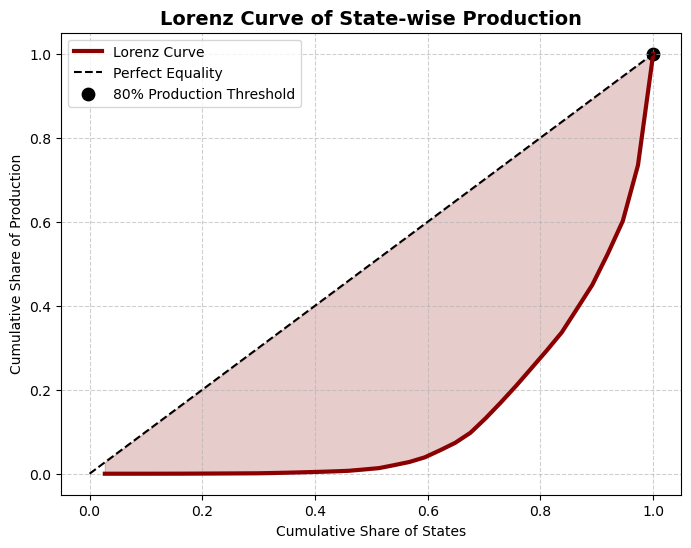

In [16]:
# Sort production by state
prod_sorted = np.sort(state_prod["production_mt"].values)
n = len(prod_sorted)

# Cumulative sum
cum_prod = np.cumsum(prod_sorted)
cum_prod = cum_prod / cum_prod[-1]  # normalize to 1

# X-axis: cumulative share of states
cum_states = np.arange(1, n+1) / n

# Gini coefficient
B = np.trapezoid(cum_prod, cum_states)  # area under Lorenz curve
Gini = 1 - 2*B

print(f"Gini Coefficient: {Gini:.3f}")

# Plot Lorenz Curve
plt.figure(figsize=(8,6))
plt.plot(cum_states, cum_prod, label="Lorenz Curve", color="darkred", linewidth=3)
plt.plot([0,1], [0,1], label="Perfect Equality", linestyle="--", color="black")
plt.fill_between(cum_states, cum_prod, cum_states, color="darkred", alpha=0.2)

plt.title("Lorenz Curve of State-wise Production", fontsize=14, weight="bold")
plt.xlabel("Cumulative Share of States")
plt.ylabel("Cumulative Share of Production")
cutoff_idx = np.argmax(cum_prod >= 0.8)
plt.scatter(cum_states[cutoff_idx], cum_prod[cutoff_idx], color="black", s=80, label="80% Production Threshold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

***Summary and Conclusion***

The Lorenz curve analysis reveals a highly unequal distribution of agricultural production across Indian states, with a Gini coefficient of 0.732 indicating strong concentration. The curve shows that approximately 20–25% of the states contribute around 80% of total production, illustrating the Pareto principle in action.<br>

This inequality highlights that a few key states dominate production, while many others have comparatively low output. These insights are crucial for policymakers and stakeholders to focus efforts on improving productivity in lower-producing states and optimizing resource allocation.

## *4. Scale vs Efficiency Analysis*
---
Agricultural output can be influenced by two major factors:

1. **Scale of cultivation (Area)**
2. **Productivity efficiency (Yield)**

This section compares states based on both production scale and productivity efficiency.  
By ranking states according to total production and yield, we can identify whether high production is driven primarily by large cultivated areas or by superior productivity.

This comparison helps distinguish between:

- **Large-scale producers**
- **High-efficiency producers**
- **States with improvement potential**

In [17]:
# Calculate the sums for Production and Area first
state_analysis = df.groupby("state").agg({
    "production_mt": "sum",
    "area_mha": "sum"
}).reset_index()

# Calculate Yield as the ratio of Total Production / Total Area
state_analysis["yield"] = state_analysis["production_mt"] / state_analysis["area_mha"]

In [18]:
state_analysis["production_rank"] = (
    state_analysis["production_mt"]
    .rank(method="dense", ascending=False)
)
state_analysis["yield_rank"] = (
    state_analysis["yield"]
    .rank(method="dense", ascending=False)
)
# production_rank > yield_rank  = Low output but high efficiency. 
# production_rank < yield_rank  = High output but low efficiency. 

In [19]:
# Sort and take top 10
top10_production = (
    state_analysis
    .sort_values(by="production_mt", ascending=False)
    .head(10)
)

# top10_yield = (
#     state_analysis
#     .sort_values(by="yield_rank", ascending=True).head(10)
# )

# Sort by yield descending and take top 10
top10_yield = (
    state_analysis
    .sort_values(by="yield", ascending=False)
    .head(10)
)

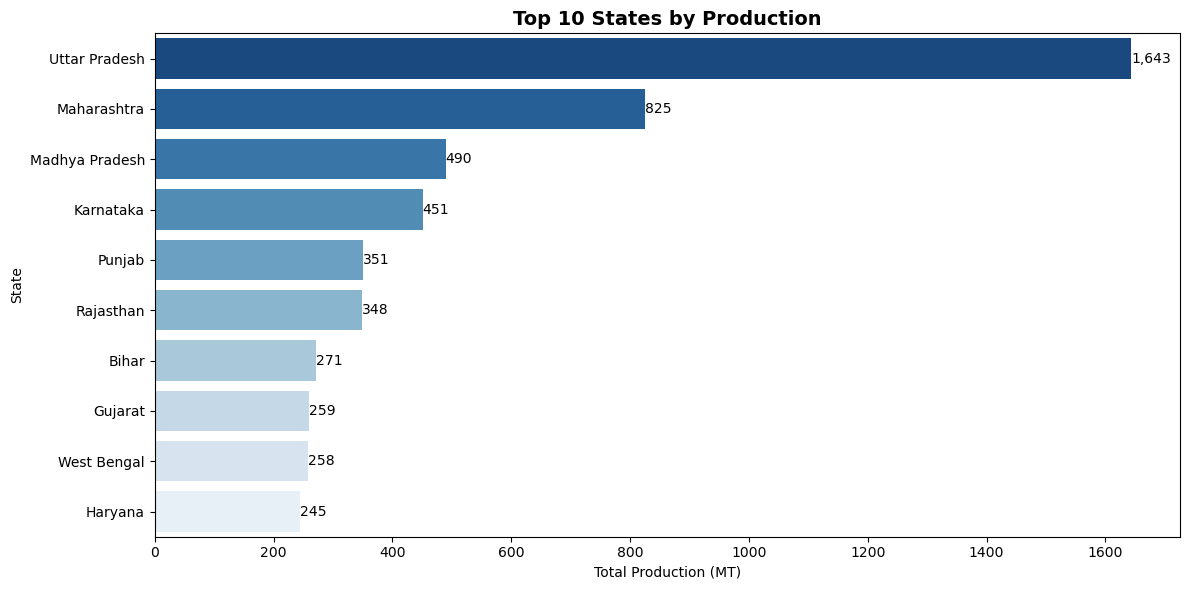

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_production,
    x="production_mt",
    y="state",
    hue = "state",
    legend = False,
    palette="Blues_r"
)

for index, value in enumerate(top10_production["production_mt"]):
    plt.text(value, index, f"{value:,.0f}", va="center")

plt.title("Top 10 States by Production", fontsize=14, weight="bold")
plt.xlabel("Total Production (MT)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

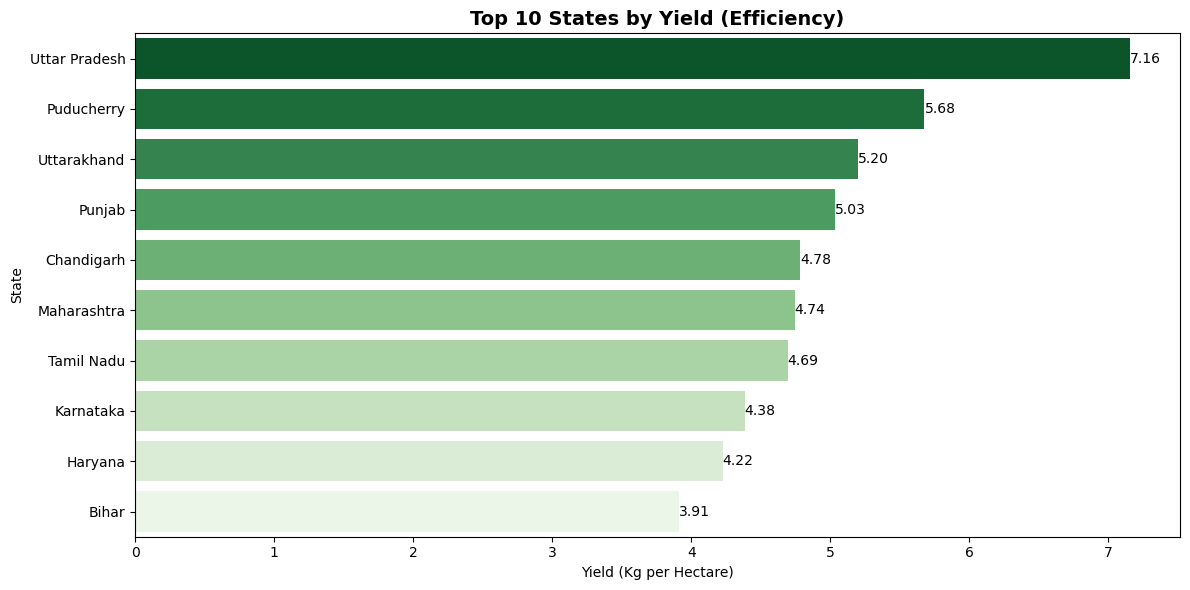

In [21]:
plt.figure(figsize=(12, 6))

# Horizontal barplot
sns.barplot(
    data=top10_yield,
    y="state",
    x="yield",
    hue = "state",
    legend = False,
    palette="Greens_r"
)

plt.title("Top 10 States by Yield (Efficiency)", fontsize=14, weight="bold")
plt.xlabel("Yield (Kg per Hectare)")
plt.ylabel("State")

# Optional: Add value labels on bars
for index, value in enumerate(top10_yield["yield"]):
    plt.text(value, index, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

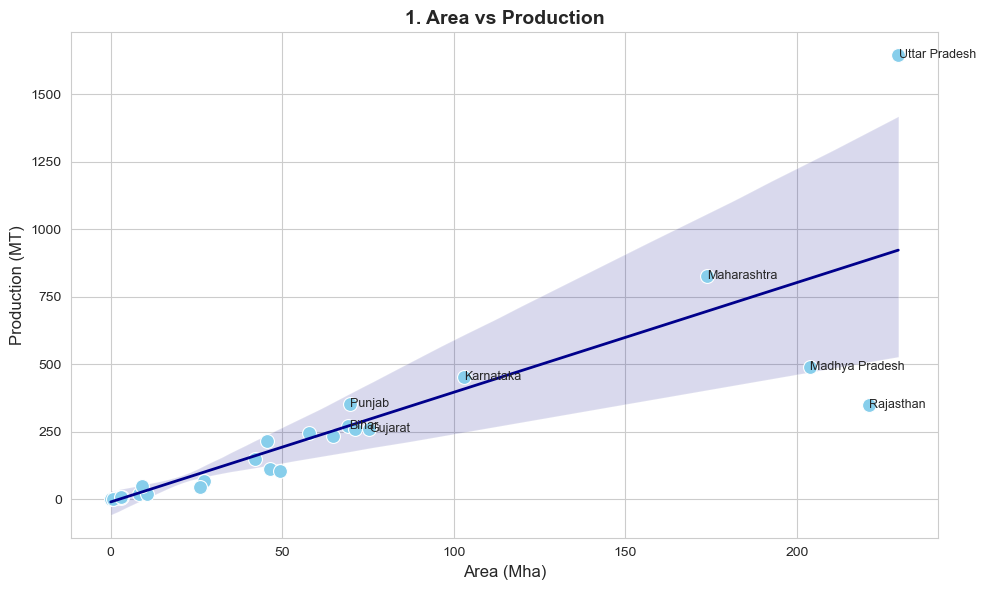

In [22]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Draw the Trend Line (Regression plot)
sns.regplot(x='area_mha', y='production_mt', data=state_analysis, 
            scatter_kws={'alpha':0.5, 'color':'blue'}, 
            line_kws={'color':'darkblue', 'linewidth':2})

# 2. Draw the Scatter Plot
sns.scatterplot(
    data=state_analysis,
    x="area_mha",
    y="production_mt",
    s=100, 
    color="skyblue",
    # edgecolor="black" # Optional: adds a border to dots for better visibility
)


# Annotate top states
for i, row in state_analysis.iterrows():
    if row["production_mt"] > state_analysis["production_mt"].quantile(0.80):
        plt.text(
            row["area_mha"] + 0.1,  # small offset
            row["production_mt"],
            row["state"],
            fontsize=9,
            ha='left',              # Horizontal alignment (left of the anchor point)
            va='center'             # Vertical alignment (centered on the anchor point)
        )


plt.title('1. Area vs Production', fontsize=14,weight="bold")

plt.xlabel("Area (Mha)",fontsize=12)
plt.ylabel("Production (MT)",fontsize=12)
plt.tight_layout()
plt.show()

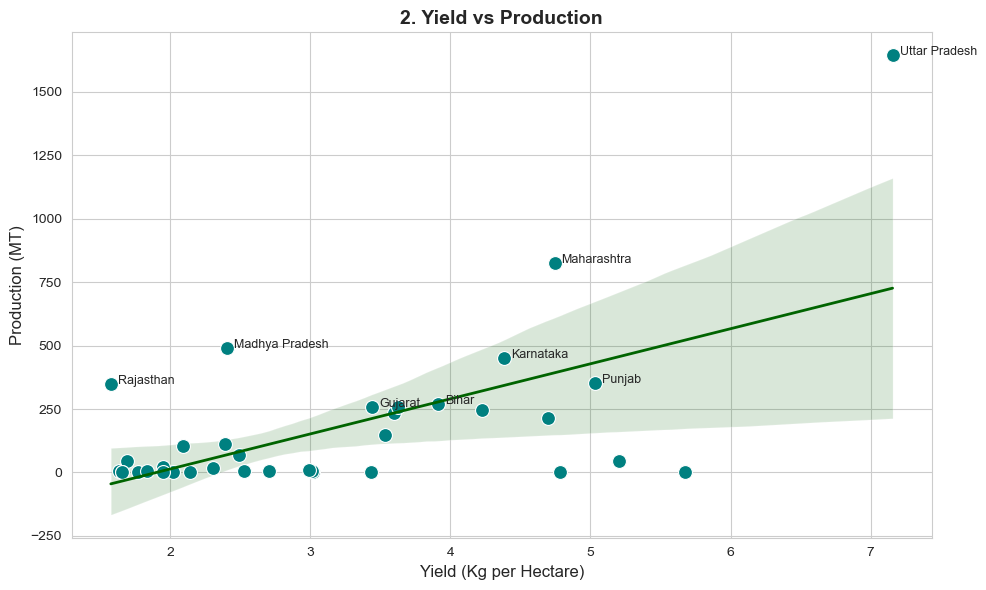

In [23]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Draw the Trend Line (Regression plot)
sns.regplot(x='yield', y='production_mt', data=state_analysis, 
            scatter_kws={'alpha':0.5, 'color':'green'}, 
            line_kws={'color':'darkgreen', 'linewidth':2})

# 2. Draw the Scatter Plot
sns.scatterplot(
    data=state_analysis,
    x="yield",
    y="production_mt",
    s=100, 
    color="teal",
    # edgecolor="black" # Optional: adds a border to dots for better visibility
)


# Annotate top states
for i, row in state_analysis.iterrows():
    if row["production_mt"] > state_analysis["production_mt"].quantile(0.80):
        plt.text(
            row["yield"] + 0.05,  # small offset
            row["production_mt"],
            row["state"],
            fontsize=9
        )
        
# plt.title("State Production vs Yield", fontsize=16, weight="bold")
plt.title('2. Yield vs Production', fontsize=14, weight="bold")

plt.xlabel('Yield (Kg per Hectare)', fontsize=12)
plt.ylabel('Production (MT)', fontsize=12)

plt.tight_layout()
plt.show()

***Scatter plot Summary*** <br>
*`1. Area vs Production & 2. Yield vs Production`* <br>
The scatter plots show a positive relationship between cultivated area and production as well as between yield and production. However, the relationship is stronger with area, indicating that total production is more directly influenced by the extent of cultivated land, while yield contributes to efficiency and productivity improvements.

In [24]:
correlation_value1 = state_analysis['area_mha'].corr(state_analysis['production_mt'])
print(f"\nCorrelation between Area and Production: {correlation_value1}")

correlation_value2 = state_analysis['yield'].corr(state_analysis['production_mt'])
print(f"\nCorrelation between Yield and Production: {correlation_value2}")



Correlation between Area and Production: 0.8489833466505566

Correlation between Yield and Production: 0.6063667082382316


<Axes: >

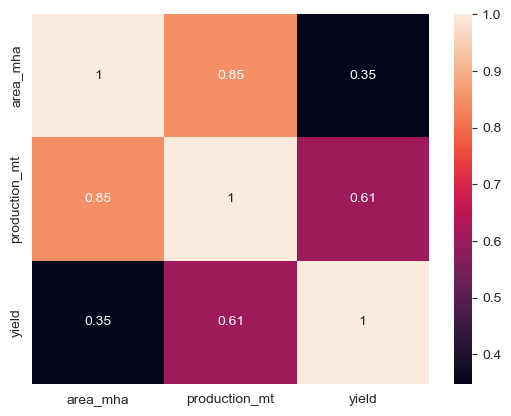

In [25]:
corr = state_analysis[["area_mha","production_mt","yield"]].corr()
sns.heatmap(corr, annot=True)

***Correlation Summary***
1. *`Area vs Production`*: The strong positive correlation (0.85) between cultivated area and total production suggests that agricultural output across states is largely influenced by the scale of land under cultivation.
2. *`Yield vs Production`*: Yield also shows a positive relationship with production (0.61), indicating that productivity improvements contribute to higher output, although the relationship is weaker compared to land allocation.<br>
Since *`Area correlation > Yield correlation`* Production dominance across states appears to be more strongly associated with the scale of cultivated land than with productivity efficiency alone.

## *5. Quadrant Structural Classification*
---
To better understand agricultural performance across states, we classify them into four structural categories based on their cultivated area and yield.

Median values of area and yield are used as thresholds to divide states into four quadrants:

1. **High Area + High Yield** – Structural leaders
2. **High Area + Low Yield** – Large producers with improvement potential
3. **Low Area + High Yield** – Efficient but small-scale states
4. **Low Area + Low Yield** – Low production and efficiency

In [26]:
# Compute median thresholds
area_median = state_analysis["area_mha"].median()
yield_median = state_analysis["yield"].median()

In [27]:
def quadrant(row):
    if row["area_mha"] >= area_median and row["yield"] >= yield_median:
        return "High Area + High Yield (Ideal)"
    elif row["area_mha"] >= area_median and row["yield"] < yield_median:
        return "High Area + Low Yield (Improve)"
    elif row["area_mha"] < area_median and row["yield"] >= yield_median:
        return "Low Area + High Yield (Efficient Niche)"
    else:
        return "Low Area + Low Yield (Low Contribution)"

state_analysis["quadrant"] = state_analysis.apply(quadrant, axis=1)

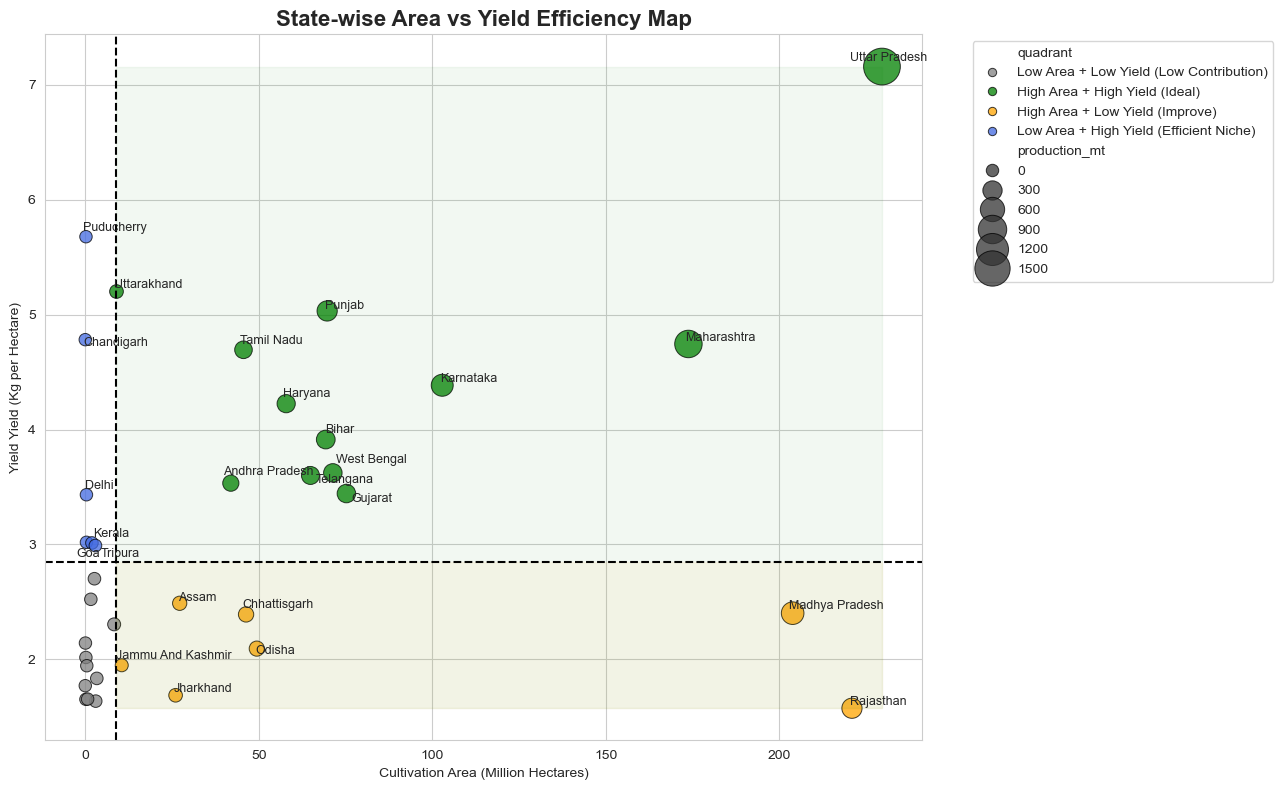

In [28]:
from adjustText import adjust_text

sns.set_style("whitegrid")

plt.figure(figsize=(13,8))

# Scatter plot
scatter = sns.scatterplot(
    data=state_analysis,
    x="area_mha",
    y="yield",
    hue="quadrant",
    size="production_mt",
    sizes=(80,700),
    palette={
        "High Area + High Yield (Ideal)": "green",
        "High Area + Low Yield (Improve)": "orange",
        "Low Area + High Yield (Efficient Niche)": "royalblue",
        "Low Area + Low Yield (Low Contribution)": "gray"
    },
    alpha=0.75,
    edgecolor="black"
)

# Median lines
plt.axvline(area_median, color="black", linestyle="--")
plt.axhline(yield_median, color="black", linestyle="--")

# Quadrant shading
plt.fill_betweenx(
    y=[state_analysis["yield"].min(), state_analysis["yield"].max()],
    x1=area_median,
    x2=state_analysis["area_mha"].max(),
    color="green",
    alpha=0.05
)

plt.fill_betweenx(
    y=[state_analysis["yield"].min(), yield_median],
    x1=area_median,
    x2=state_analysis["area_mha"].max(),
    color="orange",
    alpha=0.05
)

# Annotate states
texts = []

for i, row in state_analysis.iterrows():
    if row["yield"] > yield_median or row["area_mha"] > area_median:
        texts.append(
            plt.text(
                row["area_mha"],
                row["yield"],
                row["state"],
                fontsize=9
            )
        )

# Adjust labels to avoid overlap
adjust_text(texts)

plt.title("State-wise Area vs Yield Efficiency Map", fontsize=16, weight="bold")
plt.xlabel("Cultivation Area (Million Hectares)")
plt.ylabel("Yield Yield (Kg per Hectare)")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

## *6. Key Insights*
---
Several important insights emerge from this analysis:

1. Agricultural production in India is highly concentrated among a small group of states.
2. A strong positive relationship exists between cultivated area and total production.
3. Productivity efficiency also influences output but to a lesser extent than land scale.
4. Some smaller states demonstrate strong efficiency despite lower production scale.
5. Improving yield in large-area states could significantly increase national agricultural output.

These findings highlight opportunities for improving agricultural productivity and reducing regional imbalances in agricultural production.